# Demo 3a: Object Detection with Pretrained Models

Pretrained **Faster R-CNN** from torchvision detects objects in images.
The model is trained on COCO (80 everyday object classes). A brief look
at **Ultralytics YOLOv8** shows the fastest path to detection.

**Dataset**: Oxford-IIIT Pet — real photos of cats and dogs in natural
settings. The COCO-trained model knows both "cat" and "dog" classes, so
detection works on these images immediately.

## Setup

In [ ]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from torchvision import datasets
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    FasterRCNN_ResNet50_FPN_Weights,
)
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_tensor, to_pil_image

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: mps


## 1. Load Pretrained Faster R-CNN

In [ ]:
# Load model and weights
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)
model = model.to(device)
model.eval()

# Get class labels from the weights metadata
categories = weights.meta["categories"]
print(f"Model trained on {len(categories)} COCO classes")
print(f"First 10 classes: {categories[:10]}")

Model trained on 91 COCO classes
First 10 classes: ['__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat']


## 2. Load a Real Image

We'll use the Oxford-IIIT Pet dataset — photos of cats and dogs in
natural settings. The COCO model was trained on images like these.

Image size: (300, 225)
Pet breed label: 0


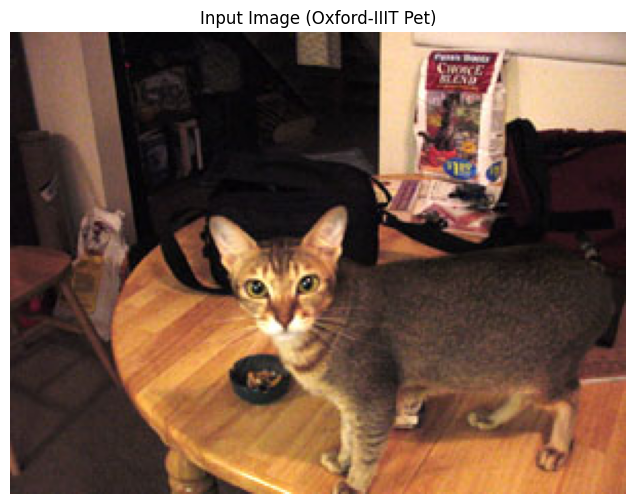

In [ ]:
# Download the Oxford-IIIT Pet dataset
pet_dataset = datasets.OxfordIIITPet(root="./data", split="test", download=True)

# Pick a few sample images
sample_indices = [0, 10, 25, 50]  # Try different indices for variety
img, label = pet_dataset[sample_indices[0]]
print(f"Image size: {img.size}")
print(f"Pet breed label: {label}")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title("Input Image (Oxford-IIIT Pet)")
plt.axis("off")
plt.show()

## 3. Run Detection

In [ ]:
# Preprocess
preprocess = weights.transforms()
img_tensor = preprocess(img).to(device)

# Run inference
with torch.no_grad():
    predictions = model([img_tensor])[0]

print(f"Detected {len(predictions['boxes'])} objects (before filtering)")
print(f"Prediction keys: {list(predictions.keys())}")

Detected 62 objects (before filtering)
Prediction keys: ['boxes', 'labels', 'scores']


In [ ]:
# Examine raw predictions
for i in range(min(5, len(predictions["boxes"]))):
    box = predictions["boxes"][i].cpu().numpy()
    label = categories[predictions["labels"][i]]
    score = predictions["scores"][i].item()
    print(
        f"  {label}: {score:.3f} — box: [{box[0]:.0f}, {box[1]:.0f}, {box[2]:.0f}, {box[3]:.0f}]"
    )

  cat: 0.967 — box: [80, 85, 288, 219]
  chair: 0.935 — box: [0, 54, 54, 163]
  book: 0.701 — box: [196, 8, 243, 86]
  chair: 0.519 — box: [45, 29, 194, 207]
  chair: 0.493 — box: [3, 50, 46, 121]


In [ ]:
# Convert image to uint8 tensor for drawing bounding boxes
img_uint8 = (to_tensor(img) * 255).byte()

## 4. What the Model Actually Outputs

Detection models produce hundreds of candidate boxes, most with very low
confidence. Confidence filtering discards the noise. This is what the raw
output looks like vs. the filtered result.

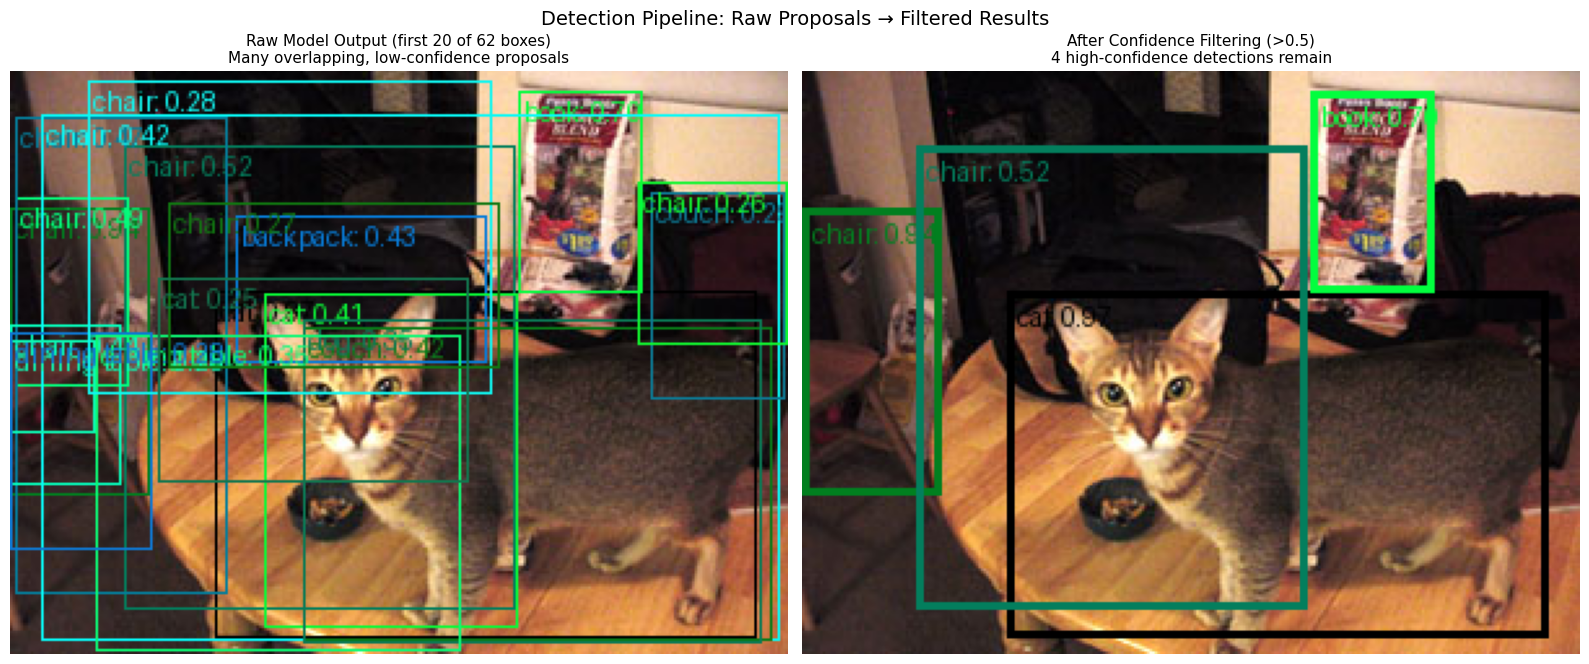

In [ ]:
# Raw output: show all predictions (capped at 20 for readability)
n_raw = min(20, len(predictions["boxes"]))
raw_names = [
    f"{categories[l]}: {s:.2f}"
    for l, s in zip(
        predictions["labels"][:n_raw], predictions["scores"][:n_raw]
    )
]
raw_result = draw_bounding_boxes(
    img_uint8, predictions["boxes"][:n_raw].cpu(), raw_names, width=1
)

# Filtered output
keep_05 = predictions["scores"] > 0.5
filt_names = [
    f"{categories[l]}: {s:.2f}"
    for l, s in zip(
        predictions["labels"][keep_05], predictions["scores"][keep_05]
    )
]
filt_result = draw_bounding_boxes(
    img_uint8, predictions["boxes"][keep_05].cpu(), filt_names, width=3
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(to_pil_image(raw_result))
axes[0].set_title(
    f"Raw Model Output (first {n_raw} of {len(predictions['boxes'])} boxes)\n"
    "Many overlapping, low-confidence proposals",
    fontsize=11,
)
axes[0].axis("off")

axes[1].imshow(to_pil_image(filt_result))
axes[1].set_title(
    f"After Confidence Filtering (>{0.5})\n"
    f"{keep_05.sum().item()} high-confidence detections remain",
    fontsize=11,
)
axes[1].axis("off")

plt.suptitle(
    "Detection Pipeline: Raw Proposals → Filtered Results", fontsize=14
)
plt.tight_layout()
plt.show()

## 5. Visualize Filtered Detections

Each surviving detection gets a labeled bounding box with its class name
and confidence score.

In [ ]:
confidence_threshold = 0.5

# Filter predictions
keep = predictions["scores"] > confidence_threshold
boxes = predictions["boxes"][keep]
labels_idx = predictions["labels"][keep]
scores = predictions["scores"][keep]

print(f"Detections above {confidence_threshold} confidence: {len(boxes)}")

Detections above 0.5 confidence: 4


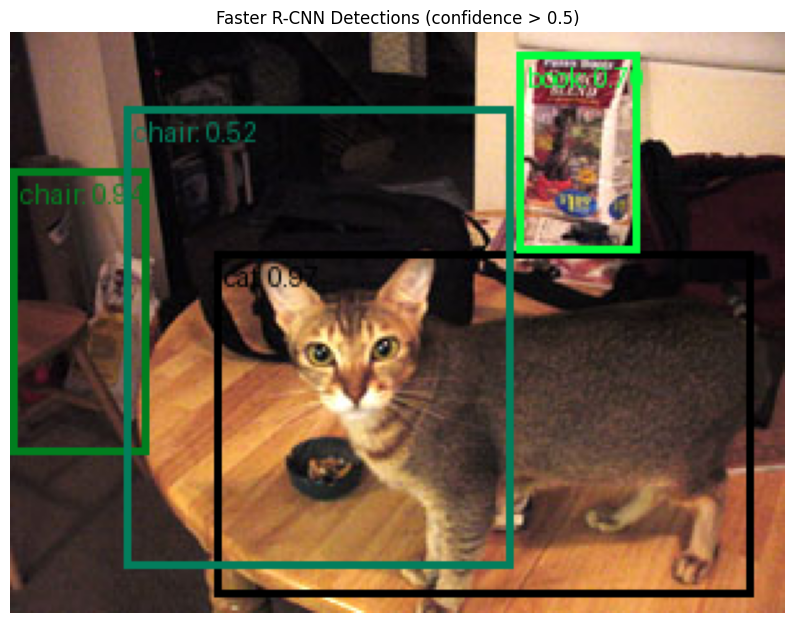

In [ ]:
# Draw bounding boxes
label_names = [f"{categories[l]}: {s:.2f}" for l, s in zip(labels_idx, scores)]
result = draw_bounding_boxes(
    img_uint8, boxes.cpu(), label_names, width=3, font_size=14
)

plt.figure(figsize=(10, 8))
plt.imshow(to_pil_image(result))
plt.title(f"Faster R-CNN Detections (confidence > {confidence_threshold})")
plt.axis("off")
plt.show()

## 6. Detection on Multiple Images

Let's run detection on several pet photos to see how the model performs
across different images and poses.

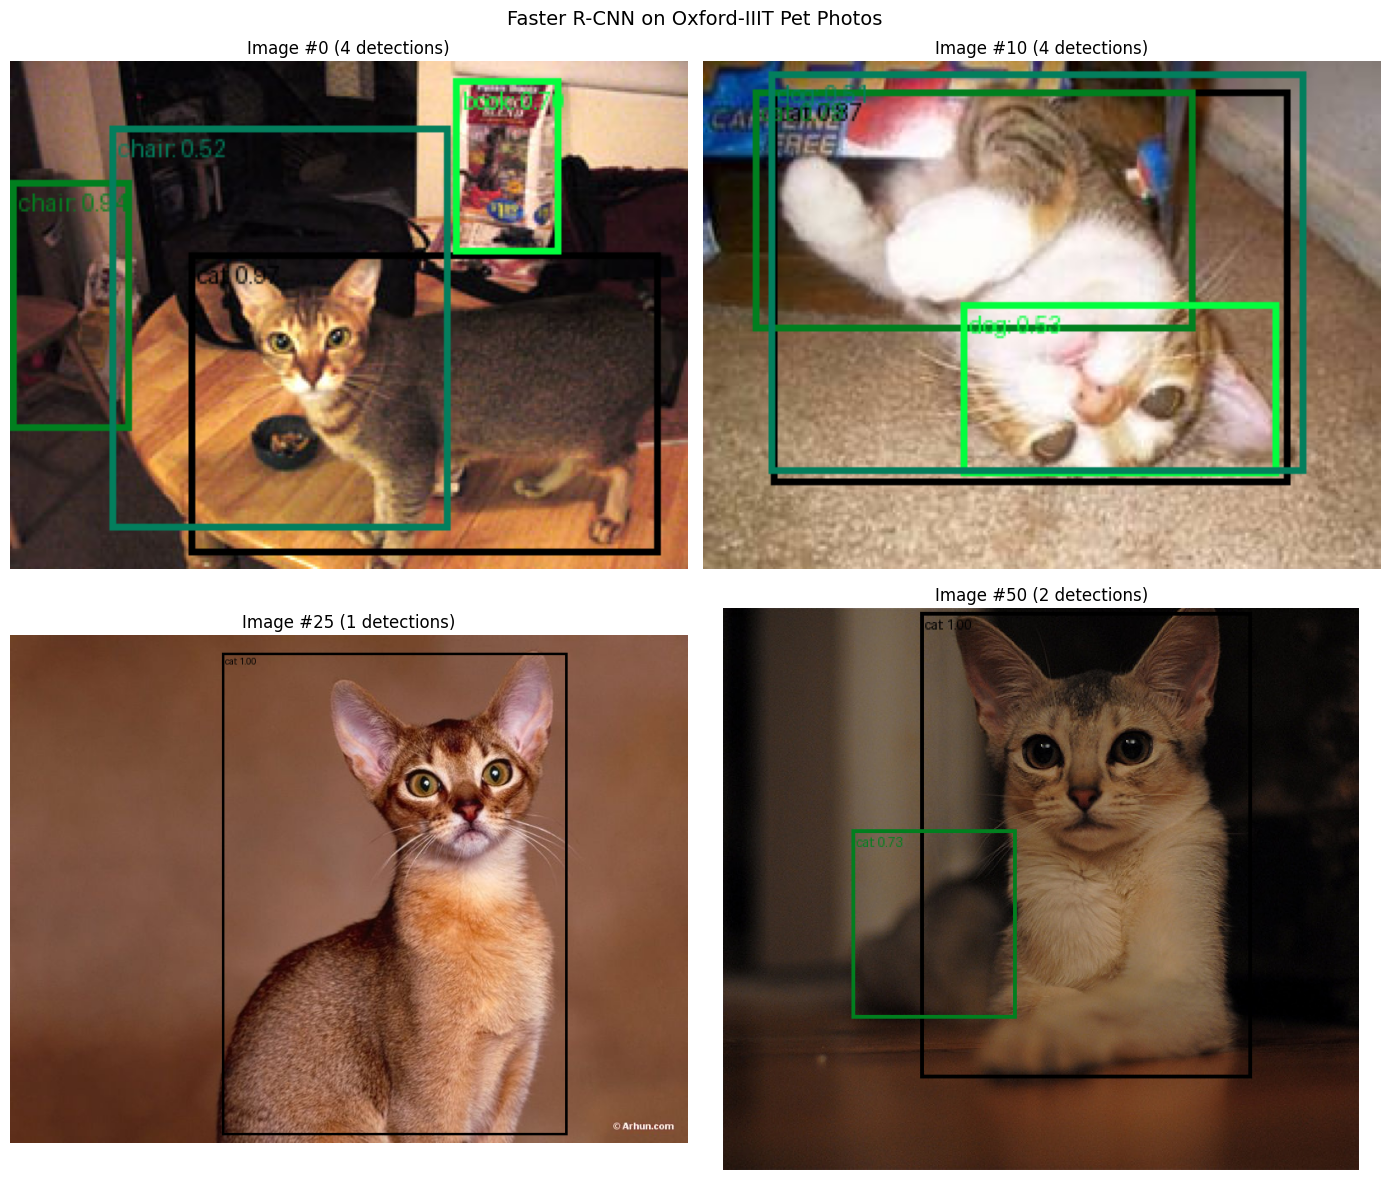

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, idx in zip(axes.flat, sample_indices):
    pet_img, _ = pet_dataset[idx]
    pet_tensor = preprocess(pet_img).to(device)

    with torch.no_grad():
        preds = model([pet_tensor])[0]

    keep = preds["scores"] > 0.5
    names = [
        f"{categories[l]}: {s:.2f}"
        for l, s in zip(preds["labels"][keep], preds["scores"][keep])
    ]
    img_u8 = (to_tensor(pet_img) * 255).byte()
    drawn = draw_bounding_boxes(
        img_u8, preds["boxes"][keep].cpu(), names, width=3
    )

    ax.imshow(to_pil_image(drawn))
    ax.set_title(f"Image #{idx} ({len(preds['boxes'][keep])} detections)")
    ax.axis("off")

plt.suptitle("Faster R-CNN on Oxford-IIIT Pet Photos", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Effect of Confidence Threshold

The threshold controls the precision-recall tradeoff: lower threshold =
more detections (higher recall) but more false positives (lower precision).

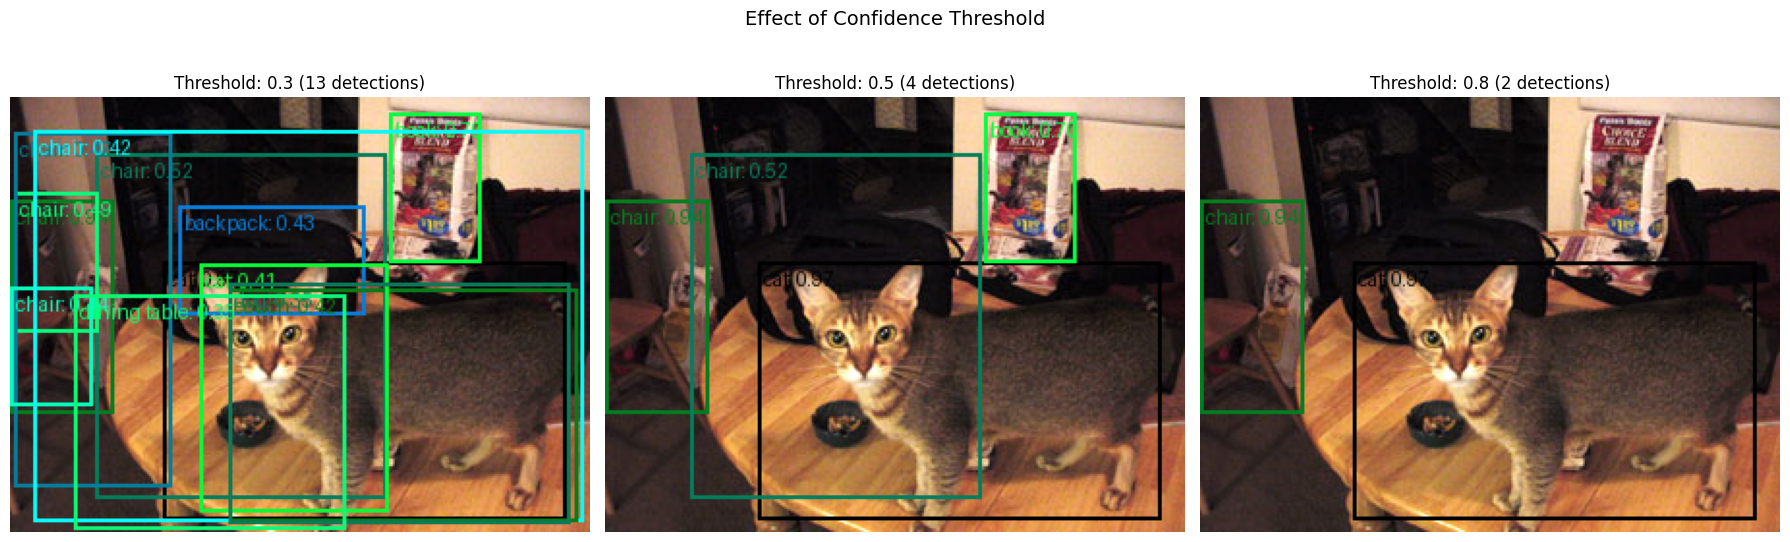

In [ ]:
# Use the first sample image
img_for_thresh, _ = pet_dataset[sample_indices[0]]
thresh_tensor = preprocess(img_for_thresh).to(device)

with torch.no_grad():
    thresh_preds = model([thresh_tensor])[0]

img_uint8_thresh = (to_tensor(img_for_thresh) * 255).byte()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, thresh in zip(axes, [0.3, 0.5, 0.8]):
    keep = thresh_preds["scores"] > thresh
    boxes_t = thresh_preds["boxes"][keep]
    labels_t = thresh_preds["labels"][keep]
    scores_t = thresh_preds["scores"][keep]

    names = [f"{categories[l]}: {s:.2f}" for l, s in zip(labels_t, scores_t)]
    result = draw_bounding_boxes(
        img_uint8_thresh, boxes_t.cpu(), names, width=2
    )

    ax.imshow(to_pil_image(result))
    ax.set_title(f"Threshold: {thresh} ({len(boxes_t)} detections)")
    ax.axis("off")

plt.suptitle("Effect of Confidence Threshold", fontsize=14)
plt.tight_layout()
plt.show()

## 8. YOLO11 with Ultralytics

Ultralytics wraps the entire detect → draw → display pipeline into a
few lines. YOLO11 is the latest generation — faster and more accurate
than earlier versions.

In [ ]:
from ultralytics import YOLO

yolo = YOLO("yolo11n.pt")  # nano model — downloads on first run (~6 MB)
print(f"Model: {yolo.model_name}, classes: {len(yolo.names)}")

Model: yolo11n.pt, classes: 80


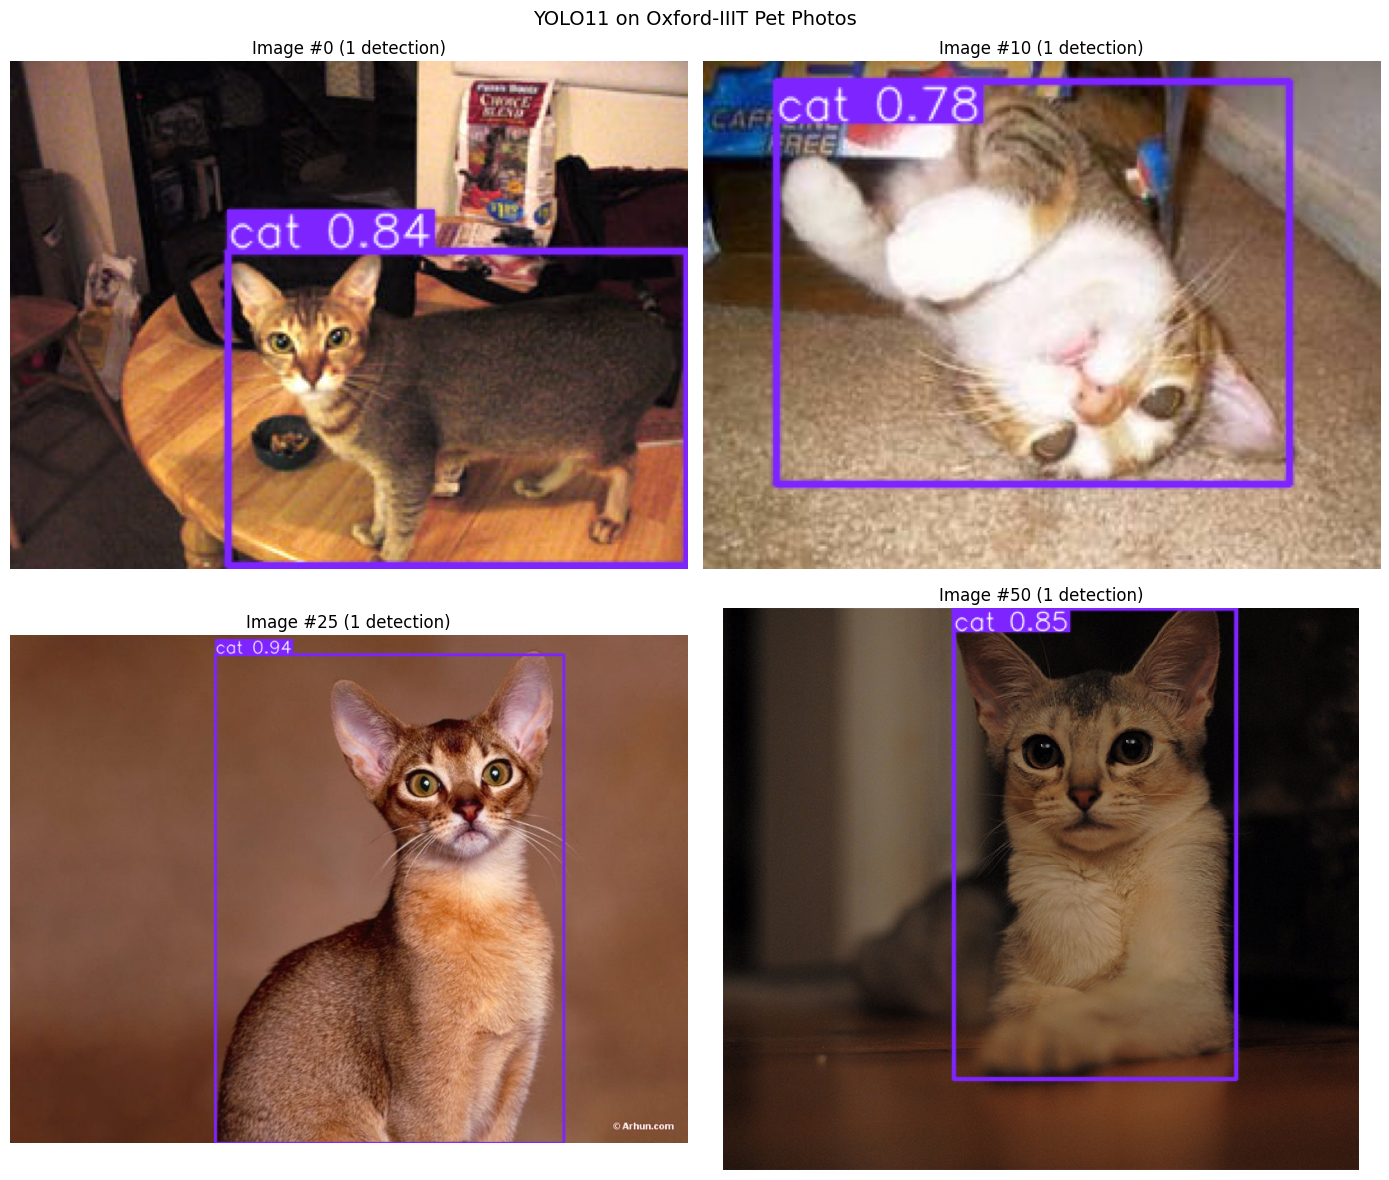

In [ ]:
# Run inference on the same pet images
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, idx in zip(axes.flat, sample_indices):
    pet_img, _ = pet_dataset[idx]

    results = yolo(pet_img, verbose=False)
    r = results[0]

    # Draw detections on the image
    annotated = r.plot()  # returns a BGR numpy array
    ax.imshow(annotated[..., ::-1])  # BGR → RGB
    n_det = len(r.boxes)
    ax.set_title(f"Image #{idx} ({n_det} detection{'s' if n_det != 1 else ''})")
    ax.axis("off")

plt.suptitle("YOLO11 on Oxford-IIIT Pet Photos", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Inspect the raw results for the first image
pet_img_0, _ = pet_dataset[sample_indices[0]]
results = yolo(pet_img_0, verbose=False)
r = results[0]

for box in r.boxes:
    cls = yolo.names[int(box.cls)]
    conf = box.conf.item()
    coords = box.xyxy[0].cpu().numpy().astype(int)
    print(f"  {cls}: {conf:.3f} — box: {list(coords)}")

  cat: 0.835 — box: [np.int64(96), np.int64(84), np.int64(299), np.int64(223)]
